✅ Data Loaded: 1460 rows, 81 columns

Top Missing Columns:
PoolQC         1453
MiscFeature    1406
Alley          1369
Fence          1179
MasVnrType      872
dtype: int64


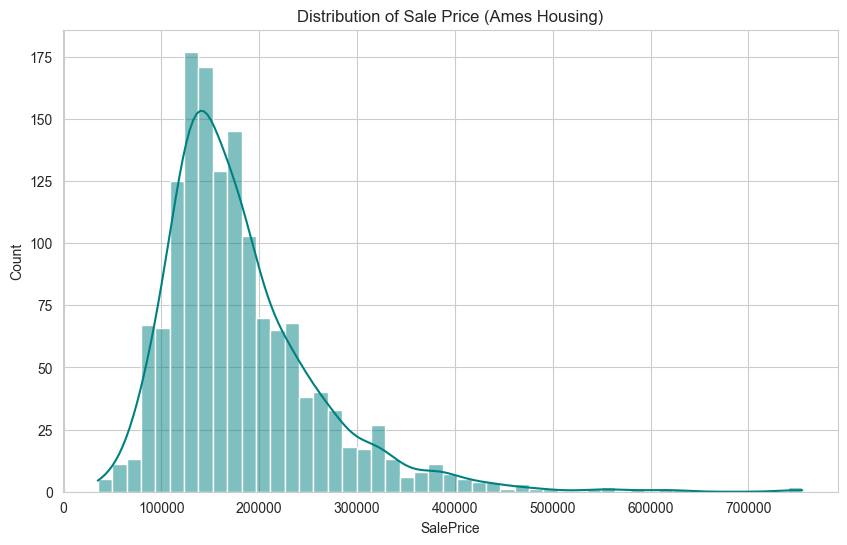

In [2]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
import os

# Professional check: Ensure we can find the data
data_path = '../data/train.csv'

if not os.path.exists(data_path):
    print("❌ Error: train.csv not found in the /data folder!")
else:
    # 1. Load Data
    df = pd.read_csv(data_path)
    print(f"✅ Data Loaded: {df.shape[0]} rows, {df.shape[1]} columns")

    # 2. Analyze Missing Values
    missing = df.isnull().sum()
    missing = missing[missing > 0].sort_values(ascending=False)
    print(f"\nTop Missing Columns:\n{missing.head(5)}")

    # 3. Visualize the Target Variable
    # This is the most important step in regression
    plt.figure(figsize=(10, 6))
    sns.set_style("whitegrid")
    sns.histplot(df['SalePrice'], kde=True, color='teal')
    plt.title('Distribution of Sale Price (Ames Housing)')
    plt.show()

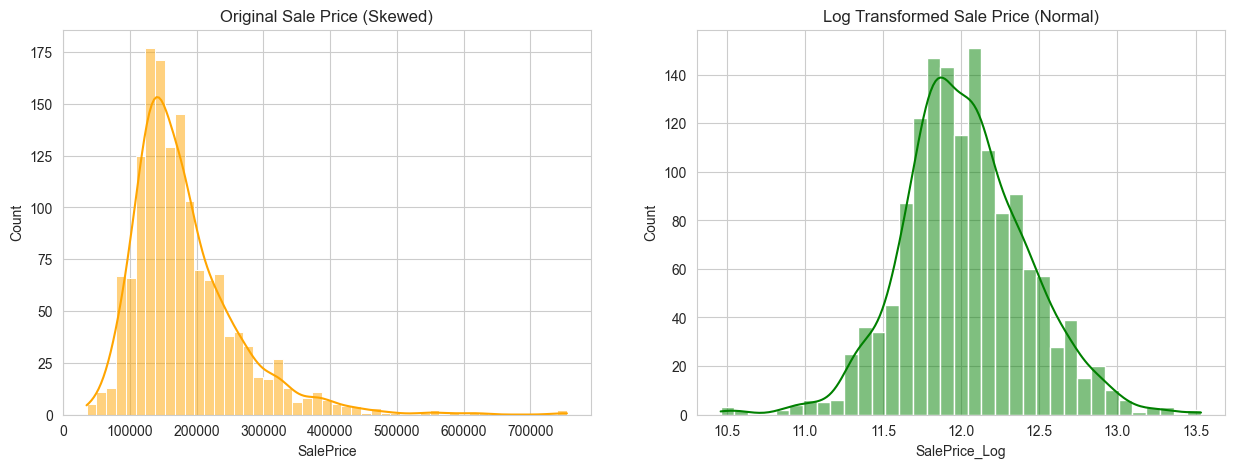

In [3]:
import numpy as np

# Apply Log transformation
df['SalePrice_Log'] = np.log1p(df['SalePrice'])

# Visualize the change
fig, ax = plt.subplots(1, 2, figsize=(15, 5))

sns.histplot(df['SalePrice'], kde=True, ax=ax[0], color='orange')
ax[0].set_title('Original Sale Price (Skewed)')

sns.histplot(df['SalePrice_Log'], kde=True, ax=ax[1], color='green')
ax[1].set_title('Log Transformed Sale Price (Normal)')

plt.show()

In [4]:
# Identify categorical columns (Object type)
cat_features = df.select_dtypes(include=['object']).columns
print(f"Total Categorical Features: {len(cat_features)}")
print(cat_features)

Total Categorical Features: 43
Index(['MSZoning', 'Street', 'Alley', 'LotShape', 'LandContour', 'Utilities',
       'LotConfig', 'LandSlope', 'Neighborhood', 'Condition1', 'Condition2',
       'BldgType', 'HouseStyle', 'RoofStyle', 'RoofMatl', 'Exterior1st',
       'Exterior2nd', 'MasVnrType', 'ExterQual', 'ExterCond', 'Foundation',
       'BsmtQual', 'BsmtCond', 'BsmtExposure', 'BsmtFinType1', 'BsmtFinType2',
       'Heating', 'HeatingQC', 'CentralAir', 'Electrical', 'KitchenQual',
       'Functional', 'FireplaceQu', 'GarageType', 'GarageFinish', 'GarageQual',
       'GarageCond', 'PavedDrive', 'PoolQC', 'Fence', 'MiscFeature',
       'SaleType', 'SaleCondition'],
      dtype='str')


C:\Users\PCP\AppData\Local\Temp\ipykernel_4000\627847463.py:2: Pandas4Warning: For backward compatibility, 'str' dtypes are included by select_dtypes when 'object' dtype is specified. This behavior is deprecated and will be removed in a future version. Explicitly pass 'str' to `include` to select them, or to `exclude` to remove them and silence this warning.
See https://pandas.pydata.org/docs/user_guide/migration-3-strings.html#string-migration-select-dtypes for details on how to write code that works with pandas 2 and 3.
  cat_features = df.select_dtypes(include=['object']).columns


In [5]:
# Define a professional mapping for quality features
qual_map = {'Ex': 5, 'Gd': 4, 'TA': 3, 'Fa': 2, 'Po': 1, 'None': 0}

# List of quality-related columns
qual_cols = ['ExterQual', 'ExterCond', 'BsmtQual', 'BsmtCond', 
             'HeatingQC', 'KitchenQual', 'FireplaceQu', 'GarageQual', 'GarageCond']

# Apply the mapping
for col in qual_cols:
    df[col] = df[col].map(qual_map).fillna(0)

print("Successfully encoded quality features as numbers.")

Successfully encoded quality features as numbers.


In [6]:
# Convert remaining categorical variables into dummy/indicator variables
df_final = pd.get_dummies(df, drop_first=True)

print(f"Original shape: {df.shape}")
print(f"New shape after encoding: {df_final.shape}")

Original shape: (1460, 82)
New shape after encoding: (1460, 224)


In [7]:
from sklearn.model_selection import train_test_split

# X = Everything EXCEPT the price (the features)
# y = The Price (the target we want to predict)
X = df_final.drop(['SalePrice', 'SalePrice_Log'], axis=1)
y = df_final['SalePrice_Log']

# Split: 80% for training, 20% for testing
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

print(f"Training on {X_train.shape[0]} houses.")
print(f"Testing on {X_test.shape[0]} houses.")

Training on 1168 houses.
Testing on 292 houses.


In [9]:
# 1. Check which columns still have missing values
print("Columns with missing values:")
print(df_final.isnull().sum()[df_final.isnull().sum() > 0])

# 2. Fill all remaining missing values with the 'Median' (the middle value)
# This is a safe bet for house data
df_final = df_final.fillna(df_final.median())

# 3. Verify they are all gone
print(f"\nRemaining missing values: {df_final.isnull().sum().sum()}")

Columns with missing values:
LotFrontage    259
MasVnrArea       8
GarageYrBlt     81
dtype: int64

Remaining missing values: 0


In [19]:
# Re-define X and y with the cleaned df_final


X = df_final.drop(['SalePrice', 'SalePrice_Log'], axis=1)
y = df_final['SalePrice_Log']

# Re-split (important to do this after filling NaNs!)
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# Try training again
model = LinearRegression()
model.fit(X_train, y_train)

print("Success! The student has finished studying the clean data.")

TypeError: LinearRegression.__new__() missing 2 required positional arguments: 'slope' and 'intercept'

R-Squared Score (Accuracy): 0.7539
Average Error: $15,339.49


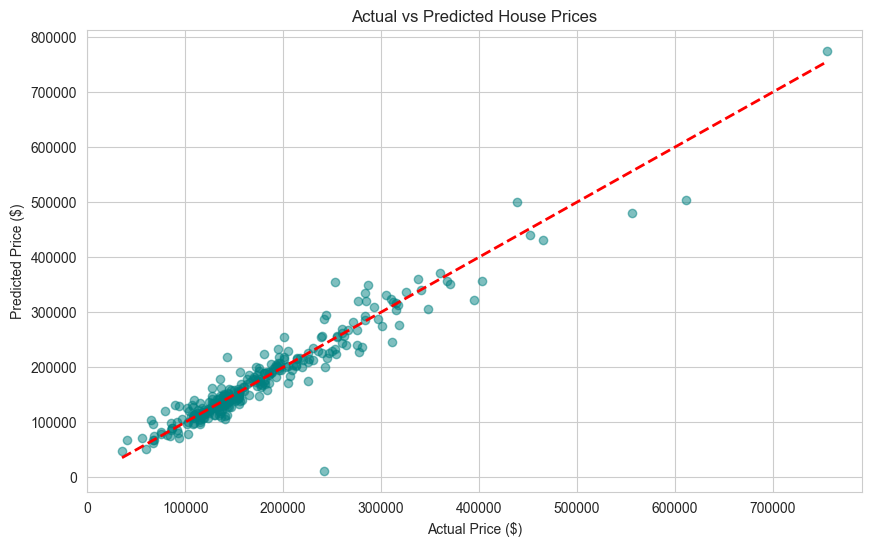

In [12]:
plt.figure(figsize=(10, 6))
plt.scatter(y_test_dollars, predictions, alpha=0.5, color='teal')
plt.plot([y_test_dollars.min(), y_test_dollars.max()], 
         [y_test_dollars.min(), y_test_dollars.max()], 
         'r--', lw=2) # The "Perfect Guess" line
plt.xlabel('Actual Price ($)')
plt.ylabel('Predicted Price ($)')
plt.title('Actual vs Predicted House Prices')
plt.show()

In [13]:
from sklearn.ensemble import RandomForestRegressor

# 1. Create a "Forest" of 100 decision trees
rf_model = RandomForestRegressor(n_estimators=100, random_state=42)

# 2. Train the forest
rf_model.fit(X_train, y_train)

# 3. Make predictions
rf_preds_log = rf_model.predict(X_test)
rf_preds = np.expm1(rf_preds_log)

# 4. Score it
rf_score = r2_score(y_test, rf_preds_log)
rf_mae = mean_absolute_error(y_test_dollars, rf_preds)

print(f"New R-Squared (Random Forest): {rf_score:.4f}")
print(f"New Average Error: ${rf_mae:,.2f}")

New R-Squared (Random Forest): 0.8839
New Average Error: $17,724.46


In [14]:
import joblib

# Save the winning model to a file
joblib.dump(rf_model, '../src/housing_model.pkl')

print("🏆 Champion model saved to /src folder!")

🏆 Champion model saved to /src folder!


In [15]:
# Save the column names so our script knows what to expect
model_columns = list(X.columns)
joblib.dump(model_columns, '../src/model_columns.pkl')
print("Column names saved!")

Column names saved!


In [17]:
# Save the exact list of 224 columns the model expects
model_columns = list(X.columns)
joblib.dump(model_columns, '../src/model_columns.pkl')

print("✅ Column names saved! The script now has the 'Map' to the model's brain.")

✅ Column names saved! The script now has the 'Map' to the model's brain.
